In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
PM_tesla_data = pd.read_csv(filepath_or_buffer="Single_electrolyser_control_algorithm_testing.csv", delimiter=",")

In [3]:
PM_tesla_data

,timestamp,status,operation_mode,grid_status,grid_power,battery_soc,battery_power,backup_reserve_percent,battery_voltage,battery_amperage,load_power,load_voltage,load_amperage,solar_power,solar_voltage,solar_amperage,frequency,nominal_full_pack_energy
0,2022-10-31 21:00:00 +0000,ok,autonomous,SystemGridConnected,5.750,83.344,817.500,5.0,217.488,-19.092,781.521,375.960,2.079,-39.250,193.190,0.838,49.937,27114.0
1,2022-10-31 21:01:00 +0000,ok,autonomous,SystemGridConnected,-3.000,83.293,783.636,5.0,219.959,-18.255,748.227,380.377,1.967,-34.636,195.457,0.823,49.913,27114.0
2,2022-10-31 21:02:00 +0000,ok,autonomous,SystemGridConnected,-15.833,83.240,836.667,5.0,221.554,-19.683,795.375,382.939,2.077,-33.167,196.778,0.828,49.939,27114.0
3,2022-10-31 21:03:00 +0000,ok,autonomous,SystemGridConnected,-5.000,83.186,779.091,5.0,222.041,-18.145,739.000,384.015,1.924,-31.273,197.338,0.831,49.991,27114.0
4,2022-10-31 21:04:00 +0000,ok,autonomous,SystemGridConnected,-1.833,83.135,700.000,5.0,221.346,-16.742,677.146,382.993,1.768,-25.333,196.795,0.839,50.050,27114.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128195,2023-01-28 20:56:00 +0000,ok,autonomous,SystemGridConnected,12.000,9.932,1168.182,5.0,227.500,-31.891,1144.205,393.102,2.911,-33.727,201.893,0.849,50.086,26898.0
128196,2023-01-28 20:57:00 +0000,ok,autonomous,SystemGridConnected,-8.000,9.850,1352.500,5.0,228.142,-35.242,1305.063,394.228,3.311,-31.000,202.471,0.841,50.096,26898.0
128197,2023-01-28 20:58:00 +0000,ok,autonomous,SystemGridConnected,8.909,9.752,1990.909,5.0,227.882,-52.882,1957.386,393.501,4.974,-40.364,202.103,0.845,50.109,26898.0
128198,2023-01-28 20:59:00 +0000,ok,autonomous,SystemGridConnected,-31.727,9.624,2240.000,5.0,228.105,-55.518,2129.386,393.760,5.408,-97.273,202.238,0.947,50.135,26898.0


In [4]:
source_consumer_power_df = PM_tesla_data[['timestamp' ,'solar_power', 'load_power']]

In [5]:
source_consumer_power_df = source_consumer_power_df.dropna()

cols = source_consumer_power_df.select_dtypes(np.number).columns
source_consumer_power_df[cols] = source_consumer_power_df[cols].clip(lower=0)

In [6]:
source_consumer_power_df

,timestamp,solar_power,load_power
0,2022-10-31 21:00:00 +0000,0.0,781.521
1,2022-10-31 21:01:00 +0000,0.0,748.227
2,2022-10-31 21:02:00 +0000,0.0,795.375
3,2022-10-31 21:03:00 +0000,0.0,739.000
4,2022-10-31 21:04:00 +0000,0.0,677.146
...,...,...,...
128195,2023-01-28 20:56:00 +0000,0.0,1144.205
128196,2023-01-28 20:57:00 +0000,0.0,1305.063
128197,2023-01-28 20:58:00 +0000,0.0,1957.386
128198,2023-01-28 20:59:00 +0000,0.0,2129.386


In [7]:
source_consumer_power_df['h2_power'] = (source_consumer_power_df['solar_power'] - source_consumer_power_df['load_power']).clip(lower=0)

In [8]:
source_consumer_power_df["timestamp"] = pd.to_datetime(source_consumer_power_df["timestamp"])

In [9]:
import unclaimed_power_planing as upp

In [10]:
generator = upp.UnclaimedPowerSourceHistoryBased(source_consumer_power_df)

In [11]:
start_timestamp = source_consumer_power_df['timestamp'][600]
time_step = 60
hours_in_episode = 12
steps_number = hours_in_episode * 3600 // time_step

In [12]:
generator.init_simulation_parameters(start_timestamp, time_step, steps_number)

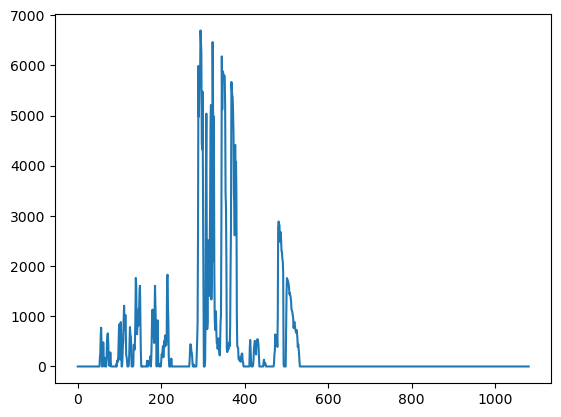

In [13]:
plt.plot(generator.h2_np_arr)
plt.show()

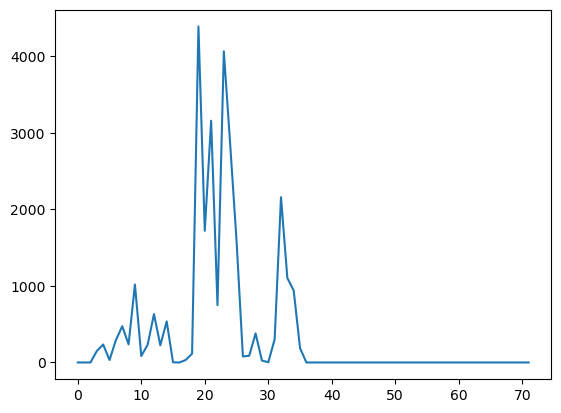

In [14]:
plt.plot(generator.h2_np_arr_aggregated)
plt.show()

In [15]:
h2_power_test = np.array([])

In [16]:
for v in generator.h2_np_arr_aggregated:
    h2_power_test = np.append(h2_power_test, v * np.ones(15))

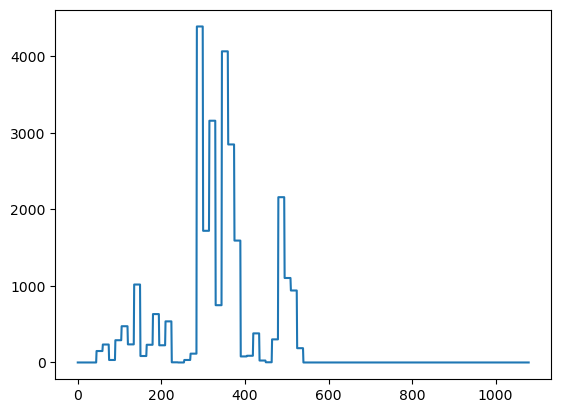

In [17]:
plt.plot(h2_power_test)
plt.show()